![Logo ITQ](./img/logoitqv1.jpg)

## Regresion Multiple Seguros Médicos

![Logo Python](./img/python_logo.png)

* Nombre: *Christian Zumárraga*
* Fecha : **30-09-2026**
* Repositorio: *[Link del repositorio de GitHub](https://github.com/Crishito/machine2/blob/main/Examen_Parcial1_Zumarraga_Christian.ipynb)*

# Carga y comprensión de los datos

In [1]:
import kagglehub
import pandas as pd
import os

In [2]:
# 1. Descarga automatizada desde Kaggle
# Se utiliza el identificador exacto del enlace proporcionado en las instrucciones
path_original = kagglehub.dataset_download("mirichoi0218/insurance")
print("El dataset ha sido descargado en:", path_original)

El dataset ha sido descargado en: C:\Users\AdministradorBlue\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [3]:
# 2. Construcción de la ruta y carga de los datos
# Asumiendo que el archivo descargado se llama 'insurance.csv'
csv_path = os.path.join(path_original, "insurance.csv")
df = pd.read_csv(csv_path)

In [4]:
# 3. Comprensión inicial de los datos
print("\n--- Primeros registros del dataset ---")
display(df.head())

print("\n--- Información general de las variables ---")
df.info()


--- Primeros registros del dataset ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Información general de las variables ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


# EDA y calidad de los datos 

In [5]:
# 1. Análisis de distribución por Condición de Fumador (smoker)
distribucion_fumador = df['smoker'].value_counts().sort_values(ascending=False)

print("=" * 60)
print("DISTRIBUCIÓN TOTAL DE REGISTROS: CONDICIÓN DE FUMADOR")
print("=" * 60)
print(distribucion_fumador)
print(f"\n")

# Calcular porcentajes
print("PORCENTAJE DE REPRESENTACIÓN:")
print("-" * 60)
for categoria, cantidad in distribucion_fumador.items():
    porcentaje = (cantidad / len(df)) * 100
    print(f"{categoria:20s}: {cantidad:5d} pacientes ({porcentaje:6.2f}%)")

print(f"\n{'TOTAL':20s}: {len(df):5d} pacientes (100.00%)")


# 2. Análisis de distribución por Región (region)
distribucion_region = df['region'].value_counts().sort_values(ascending=False)

print(f"\n{'=' * 60}")
print("DISTRIBUCIÓN TOTAL DE REGISTROS POR REGIÓN")
print("=" * 60)
print(distribucion_region)
print(f"\n")

# Calcular porcentajes
print("PORCENTAJE DE REPRESENTACIÓN:")
print("-" * 60)
for categoria, cantidad in distribucion_region.items():
    porcentaje = (cantidad / len(df)) * 100
    print(f"{categoria:20s}: {cantidad:5d} pacientes ({porcentaje:6.2f}%)")

print(f"\n{'TOTAL':20s}: {len(df):5d} pacientes (100.00%)")

DISTRIBUCIÓN TOTAL DE REGISTROS: CONDICIÓN DE FUMADOR
smoker
no     1064
yes     274
Name: count, dtype: int64


PORCENTAJE DE REPRESENTACIÓN:
------------------------------------------------------------
no                  :  1064 pacientes ( 79.52%)
yes                 :   274 pacientes ( 20.48%)

TOTAL               :  1338 pacientes (100.00%)

DISTRIBUCIÓN TOTAL DE REGISTROS POR REGIÓN
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


PORCENTAJE DE REPRESENTACIÓN:
------------------------------------------------------------
southeast           :   364 pacientes ( 27.20%)
southwest           :   325 pacientes ( 24.29%)
northwest           :   325 pacientes ( 24.29%)
northeast           :   324 pacientes ( 24.22%)

TOTAL               :  1338 pacientes (100.00%)


# Detección de outliers

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

## Box plot

limite inferior:  13.7
limite superior:  47.290000000000006
Posición de outliers:  [ 116  286  401  543  847  860 1047 1088 1317]
Número de outliers:  9


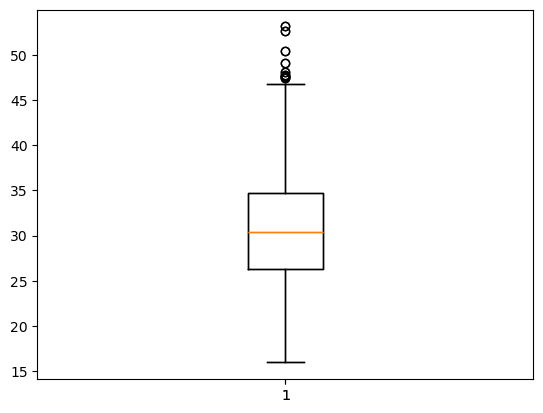


Dataset limpio (sin outliers):
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1329 rows x 7 columns]


In [7]:
# Seleccionamos el atributo que vamos a medir (Índice de Masa Corporal)
a = df['bmi']

# Seleccionamos los umbrales a partir de los cuales vamos a considerar outliers
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)
RIC = Q3 - Q1
li = Q1 - 1.5*RIC #xmin
ls = Q3 + 1.5*RIC #xmax

# Observamos los límites inferior y superior
print('limite inferior: ', li)
print('limite superior: ', ls)

# Buscamos la posición de los outliers
pos_i = np.where(a<li)[0]
pos_s = np.where(a>ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s))

print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes
prop = plt.boxplot(a)
plt.boxplot(a)
plt.show()

# Eliminamos los outliers detectados para tener el dataset limpio
new_df = df[(df['bmi'] >= li) & (df['bmi'] <= ls)].copy()

print("\nDataset limpio (sin outliers):")
print(new_df)

# Preparación de variables 

In [8]:
# Transformar variables categóricas (texto) a numéricas en nuestro dataset limpio (new_df)

# 1. Transformar 'sex' (female=0, male=1)
new_df['sex'] = new_df['sex'].map({'female': 0, 'male': 1})

# 2. Transformar 'smoker' (no=0, yes=1)
new_df['smoker'] = new_df['smoker'].map({'no': 0, 'yes': 1})

# 3. Transformar 'region' a valores numéricos
new_df['region'] = new_df['region'].map({'southwest': 1, 'southeast': 2, 'northwest': 3, 'northeast': 4})

print("--- Dataset tras la preparación de variables ---")
display(new_df.head())
print("\nVerificamos que todos los tipos de datos sean numéricos:")
new_df.info()

--- Dataset tras la preparación de variables ---


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520



Verificamos que todos los tipos de datos sean numéricos:
<class 'pandas.DataFrame'>
Index: 1329 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1329 non-null   int64  
 1   sex       1329 non-null   int64  
 2   bmi       1329 non-null   float64
 3   children  1329 non-null   int64  
 4   smoker    1329 non-null   int64  
 5   region    1329 non-null   int64  
 6   charges   1329 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 83.1 KB


# Normalización o estandarización

In [9]:
from sklearn import preprocessing

In [10]:
# Carga de datos (Separamos los atributos de la variable objetivo)
X_train = new_df.drop('charges', axis=1)
y_train = new_df['charges']

# Limpieza de datos: estandarización.
standardizer = preprocessing.StandardScaler()

# Estandarizamos los datos de entrenamiento
X_train_std = standardizer.fit_transform(X_train)
print(X_train_std)

[[-1.43876391 -1.00831144 -0.44566964 -0.90793956  1.97586919 -1.34419281]
 [-1.50997605  0.99175707  0.54626664 -0.07976408 -0.50610638 -0.44012791]
 [-0.79785463  0.99175707  0.41614893  1.57658687 -0.50610638 -0.44012791]
 ...
 [-1.50997605 -1.00831144  1.06673747 -0.90793956 -0.50610638 -0.44012791]
 [-1.29633963 -1.00831144 -0.80053612 -0.90793956 -0.50610638 -1.34419281]
 [ 1.55214607 -1.00831144 -0.24795832 -0.90793956  1.97586919  0.46393699]]


# Selección de Atributos

In [11]:
from sklearn.feature_selection import VarianceThreshold, f_regression, mutual_info_regression

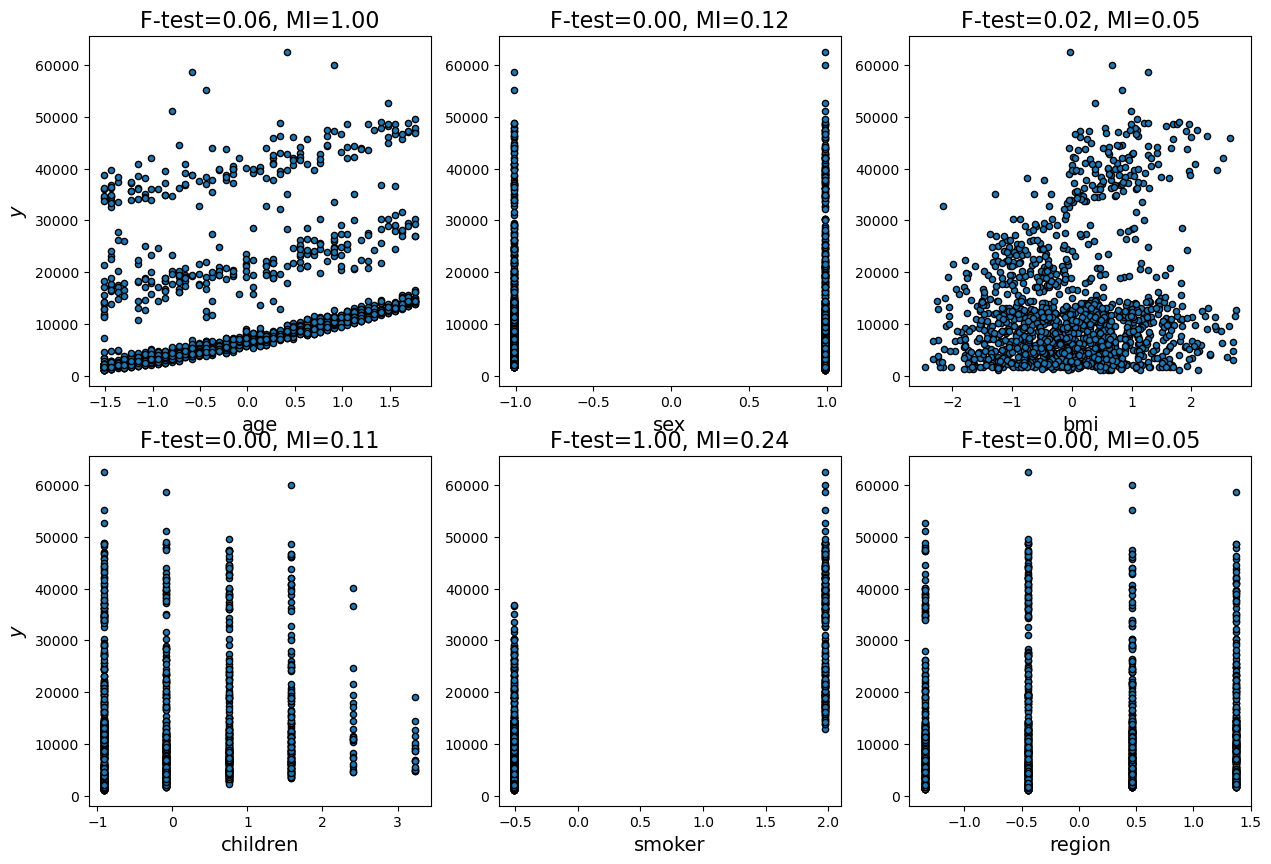

In [12]:
#Selección de Atributos II (Programa 6 - F-Test e Info. Mutua)
# Evaluación de atributos: F-Test.
f_test, _ = f_regression(X_train_std, y_train) # Llamamos al estadístico F
f_test /= np.max(f_test) # Normalizamos

# Evaluación de atributos: información mutua.
mi = mutual_info_regression(X_train_std, y_train)
mi /= np.max(mi)

# Graficamos la distribución de los datos y evaluación de atributos.
plt.figure(figsize=(15, 10)) # Ajustamos el tamaño para 6 variables
for i in range(6):
    plt.subplot(2, 3, i + 1) # 2 filas, 3 columnas
    
    # Dibujamos el diagrama de dispersión
    plt.scatter(X_train_std[:, i], y_train, edgecolor='black', s=20)
    
    # Etiqueta X con el nombre real de tu variable
    plt.xlabel("{}".format(X_train.columns[i]), fontsize=14)
    
    # Etiqueta Y solo en las gráficas que están al inicio de la fila
    if i == 0 or i == 3:
        plt.ylabel("$y$", fontsize=14)
        
    # Título exacto con los valores formateados
    plt.title("F-test={:.2f}, MI={:.2f}".format(f_test[i], mi[i]), fontsize=16)

plt.show()

# Validación de datos

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# 1) Partición de datos externa
# Dividimos nuestras variables estandarizadas (X_train_std) y nuestra variable objetivo (y_train)
X_training, X_testing, y_training, y_testing = train_test_split(
    X_train_std, y_train, test_size=0.2, random_state=42
)

print("Dimensiones de entrenamiento (X_training):", np.shape(X_training))
print("Dimensiones de prueba (X_testing):", np.shape(X_testing))

Dimensiones de entrenamiento (X_training): (1063, 6)
Dimensiones de prueba (X_testing): (266, 6)


# Entrenamiento mediante Regresión Lineal

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
# 1. Creamos y entrenamos nuestro modelo
modelo = LinearRegression()
modelo.fit(X_training, y_training)

# 2. Imprimimos el interceptor y los coeficientes
print("Interceptor: ", modelo.intercept_)
print("Pendientes (Coeficientes): ", modelo.coef_)

Interceptor:  13198.970903855596
Pendientes (Coeficientes):  [3600.21340982  -58.5022181  1946.02152813  636.55480337 9517.27176107
  498.75741593]


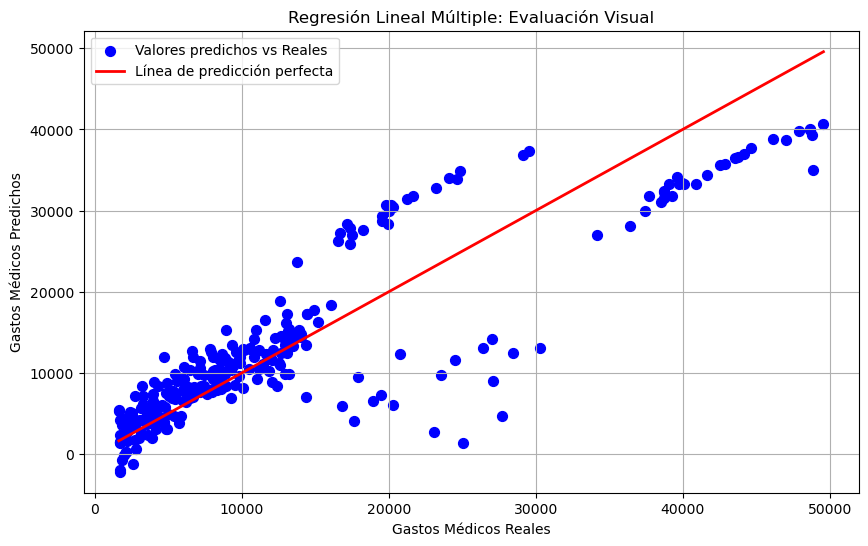

In [17]:
# 3. Valores predichos (usamos los datos de prueba para poder graficar)
y_pred = modelo.predict(X_testing)

# 4. Gráfica adaptada para Regresión Múltiple (Reales vs Predichos)
plt.figure(figsize=(10, 6))

# Dibujamos las predicciones del modelo (puntos azules)
plt.scatter(
    y_testing, 
    y_pred,
    s=50,
    color="blue",
    label="Valores predichos vs Reales"
)

# Recta de regresión ideal (línea roja de tendencia)
plt.plot(
    [y_testing.min(), y_testing.max()],
    [y_testing.min(), y_testing.max()],
    color="red",
    linewidth=2,
    label="Línea de predicción perfecta"
)

plt.xlabel("Gastos Médicos Reales")
plt.ylabel("Gastos Médicos Predichos")
plt.title("Regresión Lineal Múltiple: Evaluación Visual")
plt.legend()
plt.grid(True)
plt.show()

# Evaluación

In [18]:
from sklearn import metrics

In [19]:
# 1. Cálculo de las métricas de evaluación usando los datos de test
MAE = metrics.mean_absolute_error(y_testing, y_pred)
MSE = metrics.mean_squared_error(y_testing, y_pred)
RMSE = np.sqrt(metrics.mean_squared_error(y_testing, y_pred)) # Raíz cuadrada del MSE
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred)
R2 = metrics.r2_score(y_testing, y_pred)

# 2. Imprimimos los resultados exactos como en el Programa 12
print('MAE: %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2: %.4f' % R2)

MAE: 4099.6655
MSE: 34513457.1686
RMSE: 5874.8155
MAPE: 0.3961
R2: 0.7670


# PREDICCIÓN CON NUEVOS DATOS

In [20]:
# 1. Definimos los datos crudos de un paciente hipotético nuevo
# Orden requerido: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
# Ejemplo: Hombre(1) de 35 años, BMI normal de 24.5, 1 hijo, NO fuma(0), región Suroeste(1)
datos_nuevo_paciente = pd.DataFrame(
    [[35, 1, 24.5, 1, 0, 1]], 
    columns=X_train.columns
)

# 2. Estandarizamos estos nuevos datos
nuevo_paciente_std = standardizer.transform(datos_nuevo_paciente)

# 3. Realizamos la predicción llamando al modelo
prediccion_costo = modelo.predict(nuevo_paciente_std)

# 4. Imprimimos el resultado
print("Datos del paciente ingresado:")
display(datos_nuevo_paciente)

print(f"\nPREDICCIÓN: El gasto médico estimado será de ${prediccion_costo[0]:.2f}")

Datos del paciente ingresado:


,age,sex,bmi,children,smoker,region
0,35,1,24.5,1,0,1



PREDICCIÓN: El gasto médico estimado será de $4539.84
